# 전처리 4단계 — 파생변수: 일 가중치 w_d

## w_d란?
 
> 산불은 특정 계절에 집중됩니다. 강원도는 **3월 말~4월 초**가 가장 위험합니다.  
> w_d는 "지금이 얼마나 산불이 나기 쉬운 계절인가"를 0.33~1.0으로 표현하는 계절 가중치입니다.  
>
> **DWI 공식에서의 역할**:  
> `DWI = PreDWI_등급 × RNE × w_d`  (w_d가 낮으면 전체 위험지수도 낮아짐)

## 출처
산림청 FFDRI(산불위험지수) 알고리즘 설명서 (2026.04.20)

## 앞 파생변수들과의 차이

| | 실효습도(EH) | RNE | **w_d** |
|-|------------|-----|--------|
| 격자별 다름? | 다름 | 다름 | **전 격자 동일** |
| 계산 복잡도 | 높음 (4일 lag) | 중간 (2일 lag) | **매우 단순** |
| 결과 크기 | 3,276만 행 | 3,276만 행 | **120행** (날짜 수만) |

→ 날짜별 테이블 하나만 만들면 끝. DWI 계산 시 날짜 기준으로 join.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_PATH   = r'D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)'
OUTPUT_PATH = os.path.join(BASE_PATH, 'derived')
os.makedirs(OUTPUT_PATH, exist_ok=True)

print('설정 완료')

설정 완료


---
## Step 1. w_d 기준표 정의

> 산림청 FFDRI 기준. 3월 하순~4월 상순(1.0)이 연중 최고 위험 시기.

In [2]:
# 월/일 → w_d 반환 함수 (출처: 산림청 FFDRI)
def get_wd(month, day):
    if month == 1:            return 0.85
    if month == 2:            return 0.85
    if month == 3:
        if day <= 10:         return 0.90
        if day <= 20:         return 0.95
        return 1.00
    if month == 4:
        if day <= 10:         return 1.00
        if day <= 20:         return 0.95
        return 0.90
    if month == 5:            return 0.85
    if month == 6:            return 0.80
    if month == 7:            return 0.33
    if month == 8:            return 0.33
    if month == 9:            return 0.50
    if month == 10:           return 0.61
    if month == 11:           return 0.78
    if month == 12:           return 0.83
    return 1.0

# 데이터 기간 전체 날짜 테이블 생성 (2025-02-01 ~ 2025-05-31)
dates = pd.date_range('2025-02-01', '2025-05-31')
wd_df = pd.DataFrame({'date': dates})
wd_df['month'] = wd_df['date'].dt.month
wd_df['day']   = wd_df['date'].dt.day
wd_df['w_d']   = wd_df.apply(lambda r: get_wd(r['month'], r['day']), axis=1).astype('float32')

print(f'총 {len(wd_df)}일치 w_d 생성')
print()
print('=== 구간별 w_d 요약 ===')
for wd_val in sorted(wd_df['w_d'].unique(), reverse=True):
    rows = wd_df[wd_df['w_d'] == wd_val]
    dates_str = f'{rows["date"].min().strftime("%m/%d")} ~ {rows["date"].max().strftime("%m/%d")}'
    risk = '최고' if wd_val == 1.0 else '높음' if wd_val >= 0.9 else '중간' if wd_val >= 0.8 else '낮음'
    print(f'  w_d={wd_val:.2f}  {len(rows):3d}일  ({dates_str})  [{risk}]')

총 120일치 w_d 생성

=== 구간별 w_d 요약 ===
  w_d=1.00   21일  (03/21 ~ 04/10)  [최고]
  w_d=0.95   20일  (03/11 ~ 04/20)  [높음]
  w_d=0.90   20일  (03/01 ~ 04/30)  [중간]
  w_d=0.85   59일  (02/01 ~ 05/31)  [중간]


---
## Step 2. 저장

In [3]:
save_df = wd_df[['date', 'w_d']]
out_path = os.path.join(OUTPUT_PATH, 'w_d.parquet')
save_df.to_parquet(out_path, index=False, engine='pyarrow')

file_kb = os.path.getsize(out_path) / 1024
print(f'저장 완료: {out_path}')
print(f'파일 크기: {file_kb:.1f} KB  ({len(save_df)}행 × 2컬럼)')
print()

# 로드 확인
df_check = pd.read_parquet(out_path)
print('=== 저장된 파일 샘플 ===')
print(df_check.head(5).to_string(index=False))
print('...')
print(df_check.tail(3).to_string(index=False))

저장 완료: D:\prj_2_공모전\data\003. 전처리 데이터(preprocessing_data)\derived\w_d.parquet
파일 크기: 2.7 KB  (120행 × 2컬럼)

=== 저장된 파일 샘플 ===
      date  w_d
2025-02-01 0.85
2025-02-02 0.85
2025-02-03 0.85
2025-02-04 0.85
2025-02-05 0.85
...
      date  w_d
2025-05-29 0.85
2025-05-30 0.85
2025-05-31 0.85


---
## Step 3. 시각화 — 연간 w_d 패턴

> 1년치 w_d를 그려보면 3~4월에 봉우리가 생기는 걸 볼 수 있습니다.  
> 여름(7~8월)은 장마로 0.33까지 떨어집니다.

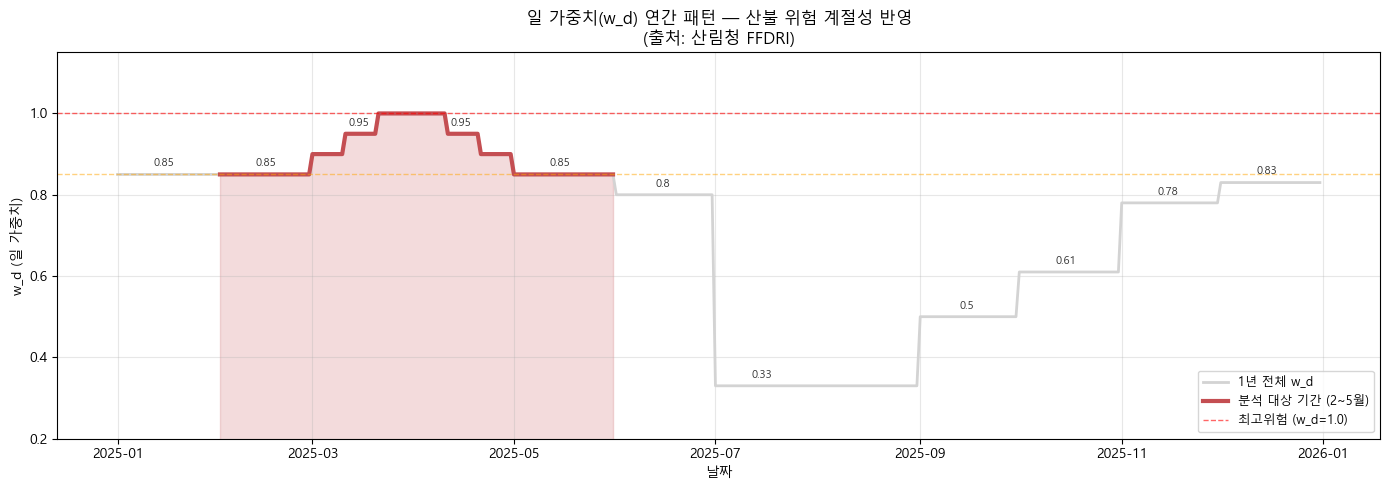

In [4]:
# 1년 전체 패턴 (데이터 없는 구간도 포함)
all_months = pd.date_range('2025-01-01', '2025-12-31')
wd_year = pd.DataFrame({'date': all_months})
wd_year['w_d'] = wd_year['date'].apply(lambda d: get_wd(d.month, d.day))

# 데이터 보유 구간 표시
has_data = (wd_year['date'] >= '2025-02-01') & (wd_year['date'] <= '2025-05-31')

fig, ax = plt.subplots(figsize=(14, 5))

# 전체 라인
ax.plot(wd_year['date'], wd_year['w_d'],
        color='lightgray', linewidth=2, label='1년 전체 w_d')

# 데이터 보유 구간 강조
wd_data = wd_year[has_data]
ax.plot(wd_data['date'], wd_data['w_d'],
        color='#C44E52', linewidth=3, label='분석 대상 기간 (2~5월)')
ax.fill_between(wd_data['date'], wd_data['w_d'], 0,
                alpha=0.2, color='#C44E52')

# 주요 기준선
ax.axhline(1.0, color='red',    linewidth=1, linestyle='--', alpha=0.6, label='최고위험 (w_d=1.0)')
ax.axhline(0.85, color='orange', linewidth=1, linestyle='--', alpha=0.5)

# 구간 레이블
for m, label, x_offset in [
    (1,'1월',15), (2,'2월',46), (3,'3월',74), (4,'4월',105),
    (5,'5월',135),(6,'6월',166),(7,'7~8월',213),(9,'9월',274),
    (10,'10월',304),(11,'11월',335),(12,'12월',365)
]:
    d = pd.Timestamp(f'2025-{m:02d}-15')
    wd = get_wd(m, 15)
    ax.text(d, wd + 0.02, f'{wd}', ha='center', fontsize=8, color='#333')

ax.set_xlabel('날짜')
ax.set_ylabel('w_d (일 가중치)')
ax.set_ylim(0.2, 1.15)
ax.set_title('일 가중치(w_d) 연간 패턴 — 산불 위험 계절성 반영\n(출처: 산림청 FFDRI)', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, 'PREP_04_일가중치패턴.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## Step 4. DWI 계산에서의 활용 방법

> w_d는 날짜만 알면 되므로, 나중에 DWI 계산 시 날짜 기준으로 간단히 붙입니다.

In [5]:
print('=== DWI 계산에서 w_d 사용 예시 ===')
print('''
# 날씨 데이터에 w_d 붙이기 (한 줄로 끝)
wd_df   = pd.read_parquet("derived/w_d.parquet")
df_dwi  = df_weather.merge(wd_df, on='date', how='left')

# DWI 공식 적용
df_dwi['DWI'] = df_dwi['PreDWI_class'] * df_dwi['rne'] * df_dwi['w_d']
''')

# 데이터 기간 w_d 분포
print('=== 분석 기간(2~5월) w_d 분포 ===')
vc = wd_df['w_d'].value_counts().sort_index(ascending=False)
for v, cnt in vc.items():
    bar = '#' * cnt
    pct = cnt / len(wd_df) * 100
    print(f'  w_d={float(v):.2f}: {cnt:3d}일 ({pct:5.1f}%)  {bar}')

=== DWI 계산에서 w_d 사용 예시 ===

# 날씨 데이터에 w_d 붙이기 (한 줄로 끝)
wd_df   = pd.read_parquet("derived/w_d.parquet")
df_dwi  = df_weather.merge(wd_df, on='date', how='left')

# DWI 공식 적용
df_dwi['DWI'] = df_dwi['PreDWI_class'] * df_dwi['rne'] * df_dwi['w_d']

=== 분석 기간(2~5월) w_d 분포 ===
  w_d=1.00:  21일 ( 17.5%)  #####################
  w_d=0.95:  20일 ( 16.7%)  ####################
  w_d=0.90:  20일 ( 16.7%)  ####################
  w_d=0.85:  59일 ( 49.2%)  ###########################################################


---
## 최종 요약

In [6]:
print('=' * 55)
print('  파생변수 3: 일 가중치 w_d 생성 완료')
print('=' * 55)
print('''
  출처: 산림청 FFDRI 알고리즘 설명서

  값 범위 (데이터 기간 2~5월)
  - w_d = 1.00 : 3월 21일 ~ 4월 10일  (산불 최고 위험기)
  - w_d = 0.95 : 3월 11~20일, 4월 11~20일
  - w_d = 0.90 : 3월 1~10일, 4월 21~30일
  - w_d = 0.85 : 2월 전체, 5월 전체

  저장 위치
  - derived/w_d.parquet  (120행 × 2컬럼)
  - 컬럼: date, w_d

  DWI 공식에서의 역할
  DWI = PreDWI_class × RNE × w_d
  -> 같은 건조 조건이라도 3월 말이 5월보다 위험하게 평가됨
''')

print('=' * 55)
print('  파생변수 3종 생성 완료 요약')
print('=' * 55)
print('''
  1. 실효습도 (EH)     derived/effective_humidity/  3,276만 행
  2. 강우효과 (RNE)    derived/rne/                 3,276만 행
  3. 일 가중치 (w_d)   derived/w_d.parquet          120행

  다음 단계: DWI(기상위험지수) 계산
  -> EH + RNE + w_d + 기온 + 풍속 조합
''')
print('=' * 55)

  파생변수 3: 일 가중치 w_d 생성 완료

  출처: 산림청 FFDRI 알고리즘 설명서

  값 범위 (데이터 기간 2~5월)
  - w_d = 1.00 : 3월 21일 ~ 4월 10일  (산불 최고 위험기)
  - w_d = 0.95 : 3월 11~20일, 4월 11~20일
  - w_d = 0.90 : 3월 1~10일, 4월 21~30일
  - w_d = 0.85 : 2월 전체, 5월 전체

  저장 위치
  - derived/w_d.parquet  (120행 × 2컬럼)
  - 컬럼: date, w_d

  DWI 공식에서의 역할
  DWI = PreDWI_class × RNE × w_d
  -> 같은 건조 조건이라도 3월 말이 5월보다 위험하게 평가됨

  파생변수 3종 생성 완료 요약

  1. 실효습도 (EH)     derived/effective_humidity/  3,276만 행
  2. 강우효과 (RNE)    derived/rne/                 3,276만 행
  3. 일 가중치 (w_d)   derived/w_d.parquet          120행

  다음 단계: DWI(기상위험지수) 계산
  -> EH + RNE + w_d + 기온 + 풍속 조합

